# Random Sample + Collate + Spectrogram
This cell pair picks a random local LibriSpeech sample, applies `collate_fn`, and visualizes the resulting mel spectrogram.

In [1]:
import matplotlib.pyplot as plt
import torch
import torchaudio
from torch.utils.data import DataLoader, Subset
from model.helpers import collate_fn_speed_perturb
from model.helpers import collate_fn_test, blank, idx2char

import os
from dotenv import load_dotenv

# Load variables from .env file
load_dotenv()

# Access the variables using os.getenv()
root = str(os.getenv("ROOT"))
train_ds = torchaudio.datasets.LIBRISPEECH(
    root=root, url="test-clean", download=True)

small_train_ds = Subset(train_ds, range(200))


train_loader = DataLoader(train_ds, collate_fn=collate_fn_speed_perturb,
                          num_workers=32, pin_memory=True, persistent_workers=True, prefetch_factor=2)


Batch size: 1
Input lengths (first 5): [1044]
Target lengths (first 5): [158]
Original audio length (sample 0): 1044 frames


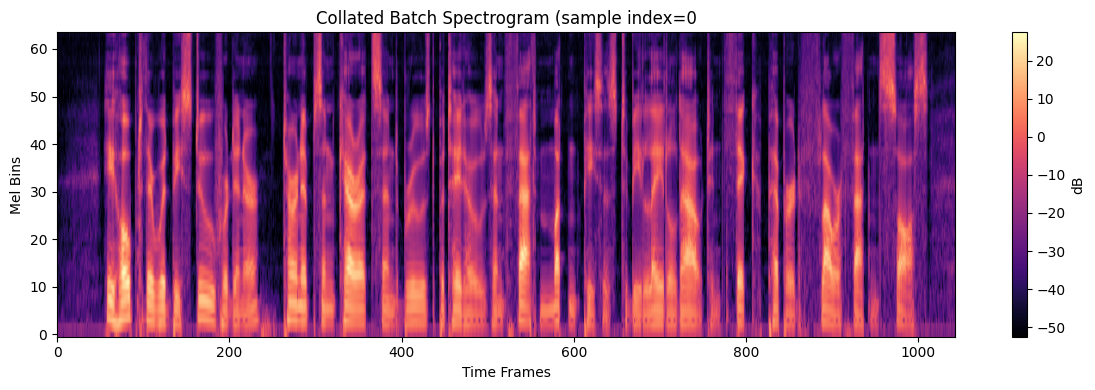

In [2]:
# Get one collated batch (this is your "df" / batch object)
df = next(iter(train_loader))
spectrogram_batch, targets_batch, input_lengths, target_lengths = df

print(f"Batch size: {len(spectrogram_batch)}")
print(f"Input lengths (first 5): {input_lengths[:5].tolist()}")
print(f"Target lengths (first 5): {target_lengths[:5].tolist()}")

# Show spectrogram of one random item from the collated batch
idx = torch.randint(0, len(spectrogram_batch), (1,)).item()
spec = spectrogram_batch[idx].detach().cpu().numpy()  # (n_mels, time)

# Crop to true (unpadded) length so padding is not shown
original_length = int(input_lengths[idx].item())
spec_no_pad = spec[:]
print(f"Original audio length (sample {idx}): {original_length} frames")

# spec_no_pad = spec[:, :original_length]
plt.figure(figsize=(12, 4))
plt.imshow(spec_no_pad, aspect="auto", origin="lower", cmap="magma")
plt.title(f"Collated Batch Spectrogram (sample index={idx}")
plt.xlabel("Time Frames")
plt.ylabel("Mel Bins")
plt.colorbar(label="dB")
plt.tight_layout()
plt.show()

In [3]:
spectrogram_batch, targets_batch, input_lengths, target_lengths = df

sample_idx = idx if 0 <= idx < len(spectrogram_batch) else 0
input_len = int(input_lengths[sample_idx].item())
target_len = int(target_lengths[sample_idx].item())

# Show the end of the spectrogram to inspect zero-padding
tail_frames = 10
print(f"\nSpectrogram tail (first 5 mel bins x last {tail_frames} frames):")
print(spectrogram_batch[sample_idx, :5, -tail_frames:])

# How many mel bins are non-zero in each of the last frames
print(f"\nNon-zero mel-bin count per last {tail_frames} frames:")
print((spectrogram_batch[sample_idx, :, -tail_frames:] != 0).sum(dim=0))

print(f"Sample index: {sample_idx}")
print(f"Spectrogram shape (padded): {tuple(spectrogram_batch[sample_idx].shape)}")
print(f"Input length (true frames): {input_len}")
print(f"Target length (true tokens): {target_len}")

print("\nTarget tokens (unpadded):")
print(targets_batch[sample_idx, :target_len])

print("\nSpectrogram snippet (first 5 mel bins x first 10 frames):")
print(spectrogram_batch[sample_idx, :5, :10])


Spectrogram tail (first 5 mel bins x last 10 frames):
tensor([[-24.6818, -21.3467, -22.1953, -21.9483, -25.2488, -25.0366, -23.9779,
         -20.3616, -27.4364, -21.0555],
        [-24.1526, -20.6615, -22.1831, -20.3630, -24.8369, -24.8314, -23.1721,
         -20.1400, -25.1178, -20.1349],
        [-23.1874, -19.4035, -22.4663, -17.8544, -24.1131, -24.5875, -21.7070,
         -19.8551, -21.9321, -18.4865],
        [-24.9223, -35.1347, -25.8022, -20.8720, -33.7675, -23.2170, -28.3903,
         -27.0565, -27.7619, -23.8685],
        [-26.4155, -26.4144, -25.8527, -25.5293, -26.7400, -24.6494, -21.9263,
         -32.5795, -25.8178, -27.7618]])

Non-zero mel-bin count per last 10 frames:
tensor([64, 64, 64, 64, 64, 64, 64, 64, 64, 64])
Sample index: 0
Spectrogram shape (padded): (64, 1044)
Input length (true frames): 1044
Target length (true tokens): 158

Target tokens (unpadded):
tensor([ 7,  4, 26,  7, 14, 15,  4,  3, 26, 19,  7,  4, 17,  4, 26, 22, 14, 20,
        11,  3, 26,  1,  4, 